DataSet Provided by:
1. https://www.kaggle.com/code/faber24/face-anti-spoofing-detection-using-mobilenetv2/input
2. https://csit.am/2019/proceedings/PRIP/PRIP3.pdf

Workflow Inspiration
1. https://www.kaggle.com/code/faber24/face-anti-spoofing-detection-using-mobilenetv2/notebook

In [41]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

import shutil

# Import Data

In [42]:
RAW_KEY = "RAW_DATA_PATH="
TRAIN_FOLDER = "LCC_FASD_training"
VAL_FOLDER = "LCC_FASD_development"
TEST_FOLDER = "LCC_FASD_evaluation"


def find_project_root(start_path: Path | None = None) -> Path:
    current_path = start_path or Path.cwd()

    for path in [current_path, *current_path.parents]:
        if (path / ".gitignore").exists():
            return path

    raise FileNotFoundError("Could not find .gitignore. Check your notebook working directory.")


def get_raw_data_path_from_gitignore() -> Path:
    project_root = find_project_root()
    gitignore_path = project_root / ".gitignore"

    lines = gitignore_path.read_text(encoding="utf-8").splitlines()

    raw_line = next(
        (line.strip() for line in lines if line.strip().startswith(RAW_KEY)),
        ""
    )

    raw_path = raw_line.removeprefix(RAW_KEY).strip()

    if not raw_path:
        raise ValueError("Missing RAW_DATA_PATH in .gitignore.")

    raw_path = Path(raw_path).expanduser()

    if not raw_path.is_absolute():
        raw_path = project_root / raw_path

    return raw_path.resolve()


def get_data_dirs() -> tuple[Path, Path, Path]:
    raw_data_dir = get_raw_data_path_from_gitignore()

    return (
        raw_data_dir / TRAIN_FOLDER,
        raw_data_dir / VAL_FOLDER,
        raw_data_dir / TEST_FOLDER,
    )


train_dir, val_dir, test_dir = get_data_dirs()

print("Train dir:", train_dir)
print("Validation dir:", val_dir)
print("Test dir:", test_dir)

print("Train exists:", train_dir.exists())
print("Validation exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

Train dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_training
Validation dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_development
Test dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation
Train exists: True
Validation exists: True
Test exists: True


# Understanding the Data

In [43]:
#Define Dataset Properties
#Image size for MobileNetV2 input; load train/val splits and preview one batch.
IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)

#Train Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True
)

#Validation Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

#Test Set
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

def get_class_counts(dataset):
    class_counts = {class_name: 0 for class_name in dataset.class_names}
    for path in dataset.file_paths:
        class_name = os.path.basename(os.path.dirname(path))
        if class_name in class_counts:
            class_counts[class_name] += 1
    return class_counts

train_counts = get_class_counts(train_ds)
val_counts = get_class_counts(val_ds)
test_counts = get_class_counts(test_ds)

summary_rows = []
for split_name, dataset, class_counts in [
    ("Train", train_ds, train_counts),
    ("Validation", val_ds, val_counts),
    ("Test", test_ds, test_counts),
]:
    row = {
        "Split": split_name,
        "Total Files": len(dataset.file_paths),
        "Num Classes": len(dataset.class_names),
    }
    for class_name in dataset.class_names:
        row[f"{class_name} Count"] = class_counts.get(class_name, 0)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


Found 8299 files belonging to 2 classes.
Found 2948 files belonging to 2 classes.
Found 7580 files belonging to 2 classes.
     Split  Total Files  Num Classes  real Count  spoof Count
     Train         8299            2        1223         7076
Validation         2948            2         405         2543
      Test         7580            2         314         7266


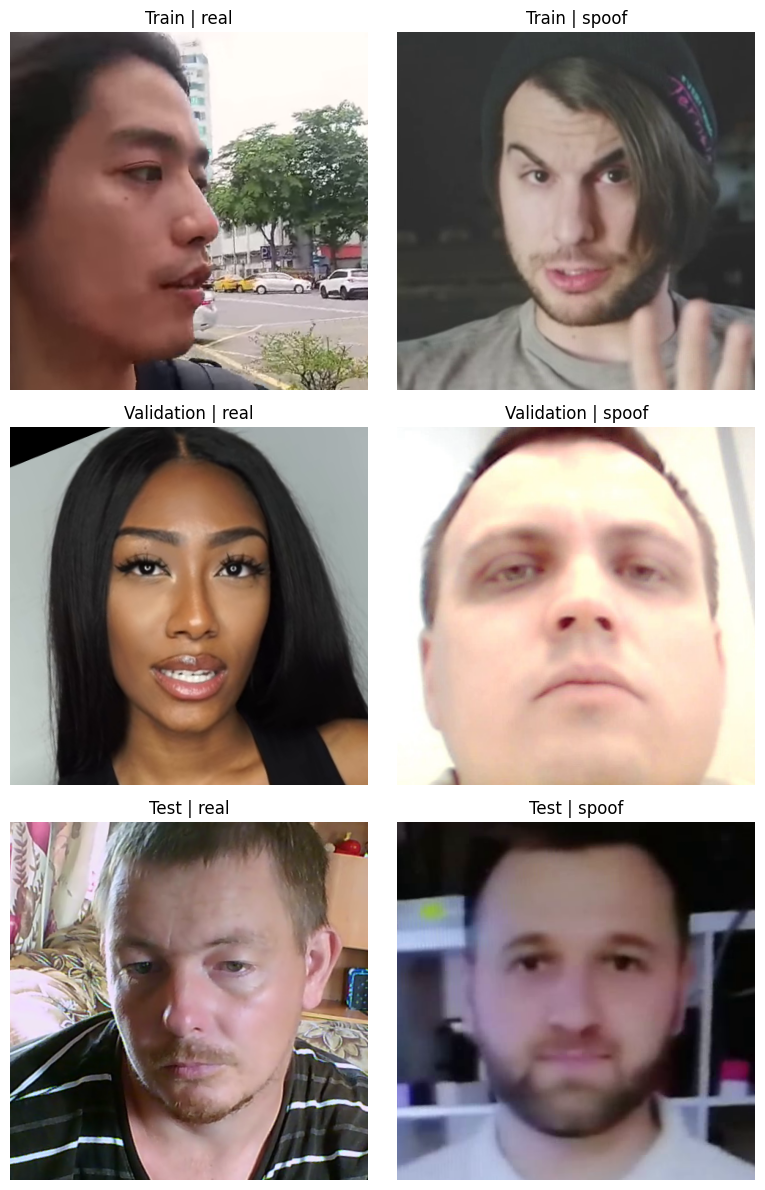

Saved image: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\data_preview.png


In [44]:
datasets = [
    ("Train", train_ds),
    ("Validation", val_ds),
    ("Test", test_ds),
]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for row, (split_name, dataset) in enumerate(datasets):
    for col, class_name in enumerate(dataset.class_names[:2]):
        class_paths = [
            path for path in dataset.file_paths
            if os.path.basename(os.path.dirname(path)) == class_name
        ]

        ax = axes[row, col]

        if class_paths:
            image_path = np.random.choice(class_paths)
            image = plt.imread(image_path)

            ax.imshow(image, cmap="gray")
            ax.set_title(f"{split_name} | {class_name}")
        else:
            ax.set_title(f"{split_name} | {class_name} (no image)")

        ax.axis("off")

plt.tight_layout()

output_path = Path.cwd() / "data_preview.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved image: {output_path}")

# Define Save Model Location

In [45]:
MODEL_DIR = Path.cwd() / "model"
MODEL_DIR.mkdir(exist_ok=True)

print("Model folder:", MODEL_DIR)

Model folder: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model


# Data Augmentation // Blanked out for now (can implement later if need)

In [46]:
# Define Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    #tf.keras.layers.RandomContrast(0.1),
])

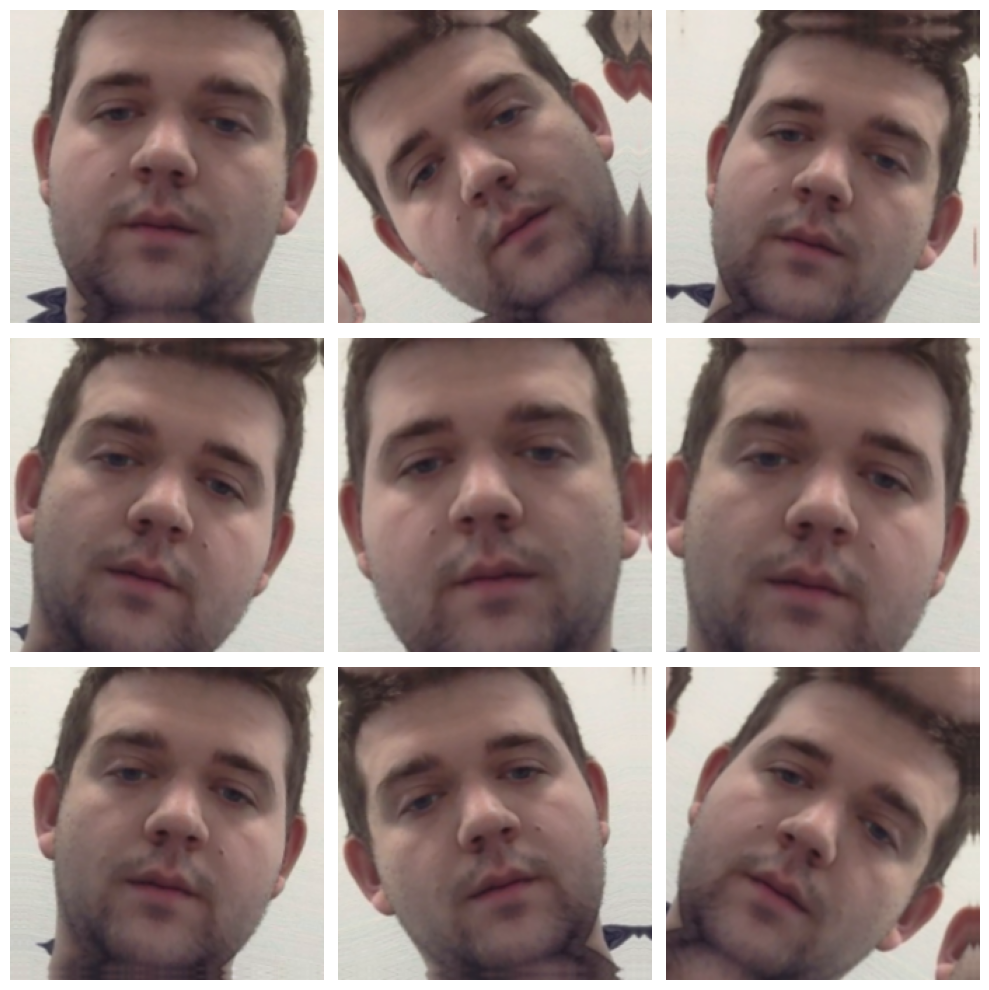

In [47]:
#Visualize several random augmentations applied to one image
for image, _ in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        #Force augmentation to be active for preview
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        augmented_image = tf.clip_by_value(augmented_image[0], 0, 255)

        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
#Halt if val_loss stops improving; restore weights from the best epoch.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#Reduce learning Rate to Squeeze as much accuracy as possible
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-8,
    verbose=1
)

#Add Checkpoint to return best model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_DIR / "best_fasd_mobilenetv2_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks = [reduce_lr, early_stop, checkpoint]

In [49]:
#Use the specific preprocessing function required for MobileNetV2 (scales pixel values to [-1, 1])
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [50]:
#Create the base model from the pre-trained model MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(preprocess_input(image_batch))
print(feature_batch.shape)

(32, 7, 7, 1280)


In [51]:
#Freeze the convolutional base
base_model.trainable = False
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [52]:
#Convert the spatial feature maps into a single feature vector per image
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [53]:
num_classes = len(train_ds.class_names)

prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 2)


In [54]:
#Build the final model architecture
inputs = tf.keras.Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)  #Ensure base model runs in inference mode

#Add convolutional layer to learn additional anti-spoofing features
x = tf.keras.layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same",
    name="anti_spoof_conv"
)(x)

x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)  #Add dropout for regularization

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [55]:
#Full model: data flow, layer types, and parameter counts.
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                           

In [56]:
#While the backbone is frozen, only the new top layers contribute trainable weights.
print(len(model.trainable_variables))


4


In [57]:
#Model Architecture Diagram

#Save Architecture
architecture_path = MODEL_DIR / "model_architecture.png"

tf.keras.utils.plot_model(
    model,
    to_file=architecture_path,
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

print(f"Saved model architecture graph: {architecture_path}")

Saved model architecture graph: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\model_architecture.png


In [58]:
#Configure the model for training
base_learning_rate = 5e-5
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

initial_epochs = 15

In [59]:
#Sanity check on the validation set before any gradient updates.
initial_loss, initial_acc = model.evaluate(val_ds)
print("Initial:")
print("Accuracy: {:.4f}".format(initial_acc))
print("Loss: {:.4f}".format(initial_loss))


93/93 [==============================] - 5s 42ms/step - loss: 0.6344 - accuracy: 0.6696
Initial:
Accuracy: 0.6696
Loss: 0.6344


In [60]:
#Get class weight

train_counts = get_class_counts(train_ds)
print(train_counts)
print(train_ds.class_names)

total = sum(train_counts.values())
num_classes = len(train_counts)

class_weight = {
    i: total / (num_classes * train_counts[class_name])
    for i, class_name in enumerate(train_ds.class_names)
}

print(class_weight)

{'real': 1223, 'spoof': 7076}
['real', 'spoof']
{0: 3.392886345053148, 1: 0.5864188807235726}


In [61]:
#Train the model using the frozen base
history = model.fit(
    train_ds,
    epochs=initial_epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/15


260/260 [==============================] - ETA: 0s - loss: 0.5036 - accuracy: 0.7385
Epoch 1: val_loss improved from inf to 0.35480, saving model to c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\best_fasd_mobilenetv2_model.keras
260/260 [==============================] - 72s 263ms/step - loss: 0.5036 - accuracy: 0.7385 - val_loss: 0.3548 - val_accuracy: 0.8402 - lr: 5.0000e-05
Epoch 2/15
260/260 [==============================] - ETA: 0s - loss: 0.3867 - accuracy: 0.8179
Epoch 2: val_loss improved from 0.35480 to 0.30871, saving model to c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\best_fasd_mobilenetv2_model.keras
260/260 [==============================] - 70s 266ms/step - loss: 0.3867 - accuracy: 0.8179 - val_loss: 0.3087 - val_accuracy: 0.8680 - lr: 5.0000e-05
Epoch 3/15
260/260 [==============================] - ETA: 0s - l

Text(0.5, 1.0, 'Training and Validation Accuracy')

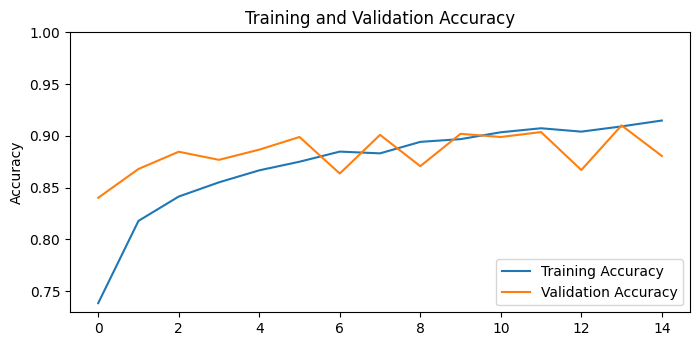

In [62]:
#Extract training results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

#Visualize training and validation metrics
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

In [63]:
#Evaluate feature extraction model before fine-tuning
feature_loss, feature_acc = model.evaluate(val_ds)

print("Feature Extraction:")
print("Accuracy: {:.4f}".format(feature_acc))
print("Loss: {:.4f}".format(feature_loss))

93/93 [==============================] - 4s 44ms/step - loss: 0.2700 - accuracy: 0.8806
Feature Extraction:
Accuracy: 0.8806
Loss: 0.2700


# Fine Tuning

In [64]:
#Unfreeze the base model for fine-tuning
base_model.trainable = True

In [65]:
#MobileNetV2 depth — used to choose where fine-tuning starts.
print("Number of layers in the base model: ", len(base_model.layers))


Number of layers in the base model:  154


In [66]:
#Layers below this index stay frozen; deeper layers adapt to classes
fine_tune_at = 160


In [67]:
#Keep the first 'fine_tune_at' layers frozen to preserve general features
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [68]:
#Add Model Chckepoint to restore best model based on val-loss

In [69]:
#Recompile with a lower learning rate for fine-tuning
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=1e-6),
              metrics=['accuracy'])

In [70]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                           

In [71]:
#After selective unfreezing, more layers (and weights) are trainable.
len(model.trainable_variables)

4

In [72]:
#Continue training the model
fine_tune_epochs = 15
feature_epochs_ran = len(history.epoch)

total_epochs = feature_epochs_ran + fine_tune_epochs


history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=feature_epochs_ran,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight
)

best_model_path = MODEL_DIR / "best_fasd_mobilenetv2_model.keras"

#Load the best validation-loss model before final evaluation
model = tf.keras.models.load_model(best_model_path)

print(f"Loaded best model from: {best_model_path}")

Epoch 16/30
260/260 [==============================] - ETA: 0s - loss: 0.2296 - accuracy: 0.9029
Epoch 16: val_loss did not improve from 0.23912
260/260 [==============================] - 76s 276ms/step - loss: 0.2296 - accuracy: 0.9029 - val_loss: 0.2524 - val_accuracy: 0.8952 - lr: 1.0000e-06
Epoch 17/30
260/260 [==============================] - ETA: 0s - loss: 0.2239 - accuracy: 0.9120
Epoch 17: val_loss did not improve from 0.23912
260/260 [==============================] - 74s 282ms/step - loss: 0.2239 - accuracy: 0.9120 - val_loss: 0.2506 - val_accuracy: 0.8982 - lr: 1.0000e-06
Epoch 18/30
260/260 [==============================] - ETA: 0s - loss: 0.2204 - accuracy: 0.9111
Epoch 18: val_loss did not improve from 0.23912
260/260 [==============================] - 72s 276ms/step - loss: 0.2204 - accuracy: 0.9111 - val_loss: 0.2505 - val_accuracy: 0.8979 - lr: 1.0000e-06
Epoch 19/30
260/260 [==============================] - ETA: 0s - loss: 0.2237 - accuracy: 0.9085
Epoch 19: val_l

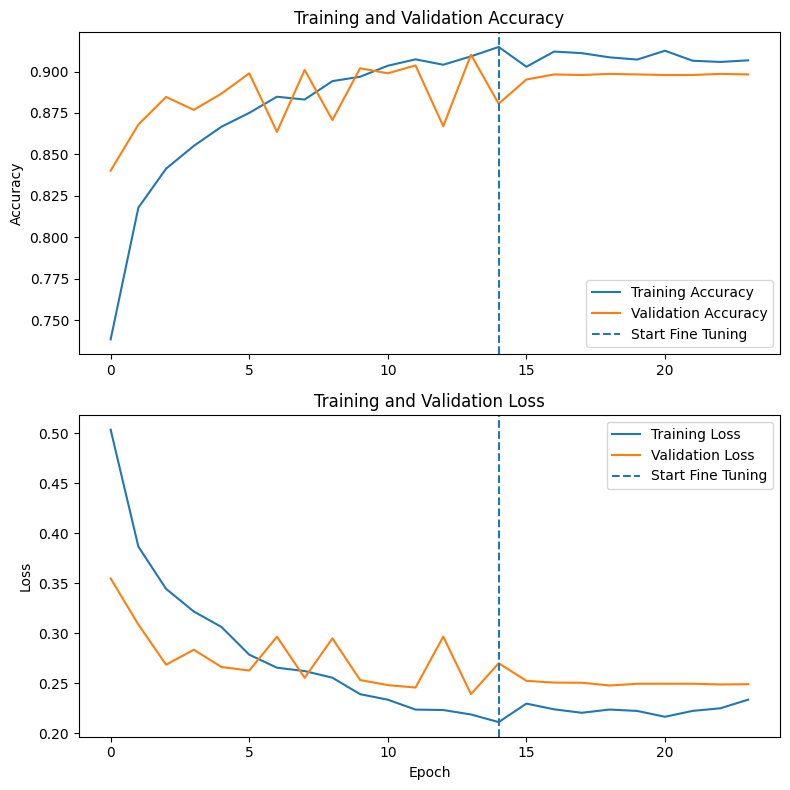

Saved training graph: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\training_graph.png


In [73]:
#Combine histories and plot learning curves before and after fine-tuning
full_acc = history.history["accuracy"] + history_fine.history["accuracy"]
full_val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

full_loss = history.history["loss"] + history_fine.history["loss"]
full_val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

fine_tune_start = len(history.history["accuracy"])

training_graph_path = MODEL_DIR / "training_graph.png"

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(full_acc, label="Training Accuracy")
plt.plot(full_val_acc, label="Validation Accuracy")
plt.axvline(fine_tune_start - 1, linestyle="--", label="Start Fine Tuning")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.ylabel("Accuracy")

plt.subplot(2, 1, 2)
plt.plot(full_loss, label="Training Loss")
plt.plot(full_val_loss, label="Validation Loss")
plt.axvline(fine_tune_start - 1, linestyle="--", label="Start Fine Tuning")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.savefig(training_graph_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved training graph: {training_graph_path}")

In [74]:
#Fine-tuned evaluation
fine_tune_loss, fine_tune_acc = model.evaluate(val_ds)
print("\nFine-Tuning:")
print("Accuracy: {:.4f}".format(fine_tune_acc))
print("Loss: {:.4f}".format(fine_tune_loss))

93/93 [==============================] - 5s 44ms/step - loss: 0.2391 - accuracy: 0.9101

Fine-Tuning:
Accuracy: 0.9101
Loss: 0.2391


In [75]:
print("\nStage\t\t\tAccuracy\tLoss")
print("Initial\t\t\t{:.4f}\t\t{:.4f}".format(initial_acc, initial_loss))
print("Feature Extraction\t{:.4f}\t\t{:.4f}".format(feature_acc, feature_loss))
print("Fine-Tuning\t\t{:.4f}\t\t{:.4f}".format(fine_tune_acc, fine_tune_loss))


Stage			Accuracy	Loss
Initial			0.6696		0.6344
Feature Extraction	0.8806		0.2700
Fine-Tuning		0.9101		0.2391


In [76]:
#Test df
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

237/237 [==============================] - 11s 45ms/step - loss: 0.1459 - accuracy: 0.9449
Test Accuracy: 0.9448548555374146
Test Loss: 0.145854189991951


237/237 [==============================] - 11s 43ms/step


<Figure size 600x600 with 0 Axes>

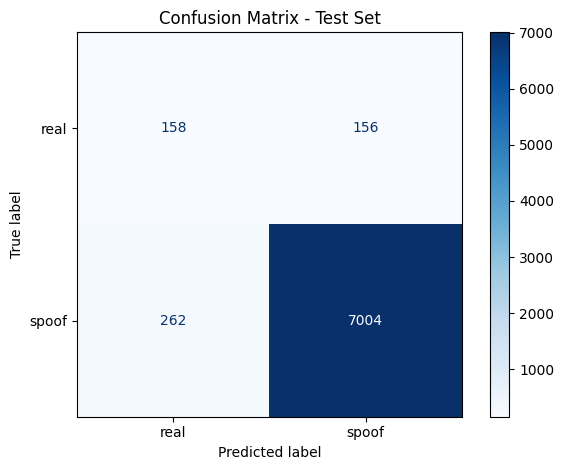

Saved confusion matrix: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\confusion_matrix.png
              precision    recall  f1-score   support

        real       0.38      0.50      0.43       314
       spoof       0.98      0.96      0.97      7266

    accuracy                           0.94      7580
   macro avg       0.68      0.73      0.70      7580
weighted avg       0.95      0.94      0.95      7580



In [77]:
#Create Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#Get true labels from test dataset
y_true = np.concatenate([labels.numpy() for images, labels in test_ds])

#Get model predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

#Use class names from training set
class_names = train_ds.class_names

#Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

#Save confusion matrix image
confusion_matrix_path = MODEL_DIR / "confusion_matrix.png"

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix: {confusion_matrix_path}")

#print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

In [78]:
#Save Model
model_path = MODEL_DIR / "fasd_mobilenetv2_model.keras"

model.save(model_path)

print(f"Saved model: {model_path}")

Saved model: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\fasd_mobilenetv2_model.keras
